In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install nltk scikit-learn pandas numpy
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tabokenizer')
print("All libraries ready!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries ready!


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Error loading punkt_tabokenizer: Package
[nltk_data]     'punkt_tabokenizer' not found in index


In [3]:
from google.colab import files
uploaded = files.upload()

Saving resume_data.csv to resume_data.csv


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('resume_data.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(9544, 35)
['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', '\ufeffjob_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score']
  address                                   career_objective  \
0     NaN  Big data analytics working and database wareho...   
1     NaN  Fresher looking to join as a data analyst and ...   
2     NaN                                                

In [6]:
print(df.columns.tolist())
print(df.head(2))

['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', '\ufeffjob_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score']
  address                                   career_objective  \
0     NaN  Big data analytics working and database wareho...   
1     NaN  Fresher looking to join as a data analyst and ...   

                                              skills  \
0  ['Big Da

In [9]:
print(df.columns.tolist())

['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', '\ufeffjob_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score']


In [10]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Fix the BOM character in column name
df.columns = df.columns.str.strip().str.replace('\ufeff', '')

df['combined_text'] = (
    df['career_objective'].fillna('') + ' ' +
    df['skills'].fillna('') + ' ' +
    df['responsibilities.1'].fillna('') + ' ' +
    df['job_position_name'].fillna('')
)

df['cleaned_resume'] = df['combined_text'].apply(clean_text)
print("Cleaning done!")
print(df['cleaned_resume'][0][:300])

Cleaning done!
big data analytics working database warehouse manager robust experience handling kind data also used multiple cloud infrastructure service well acquainted currently search role offer development big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java data science 


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(max_features=1500)
X = tfidf.fit_transform(df['cleaned_resume'])

job_description = """
python machine learning data science pandas numpy scikit-learn
deep learning neural network tensorflow keras data analysis
visualization matplotlib seaborn sql statistics
"""
cleaned_jd = clean_text(job_description)
jd_vector = tfidf.transform([cleaned_jd])

similarity_scores = cosine_similarity(jd_vector, X).flatten()
df['match_score'] = similarity_scores
df['match_percent'] = (df['match_score'] * 100).round(2)
print("Matching done!")

Matching done!


In [12]:
ranked_df = df[['job_position_name', 'match_percent']].sort_values(
    by='match_percent', ascending=False).reset_index(drop=True)
ranked_df.index += 1

print("TOP 10 MATCHING RESUMES")
print("=" * 45)
print(ranked_df.head(10).to_string())

TOP 10 MATCHING RESUMES
        job_position_name  match_percent
1           Data Engineer          44.48
2           Data Engineer          43.33
3   Data Science Engineer          41.90
4           Data Engineer          41.60
5     Mechanical Engineer          40.88
6             AI Engineer          40.76
7   Data Science Engineer          40.38
8           Data Engineer          39.83
9   Data Science Engineer          39.49
10            AI Engineer          39.37


/tmp/ipykernel_3108/3497418064.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rank', y='match_percent', data=top10, palette='Blues_r')


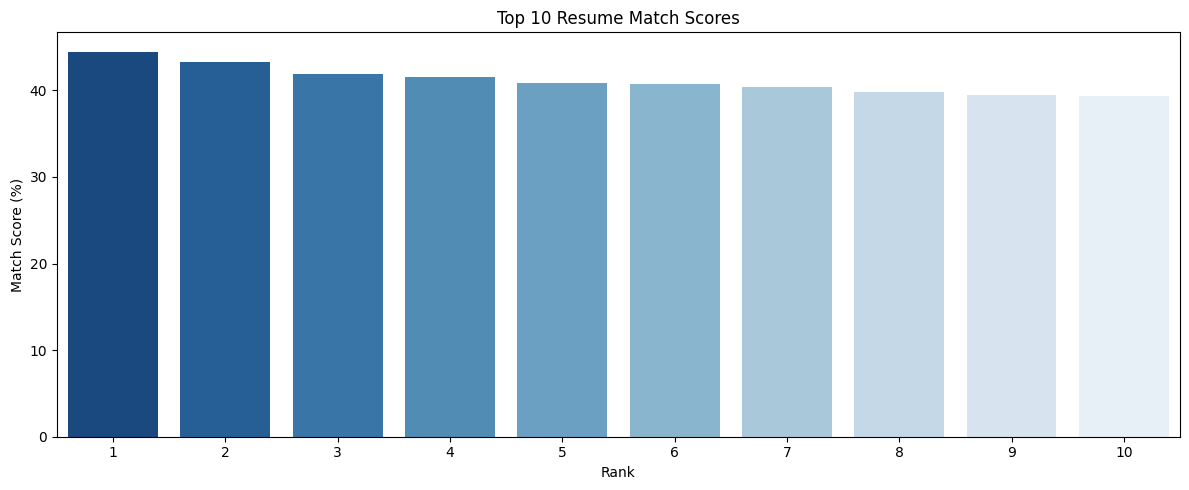

/tmp/ipykernel_3108/3497418064.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


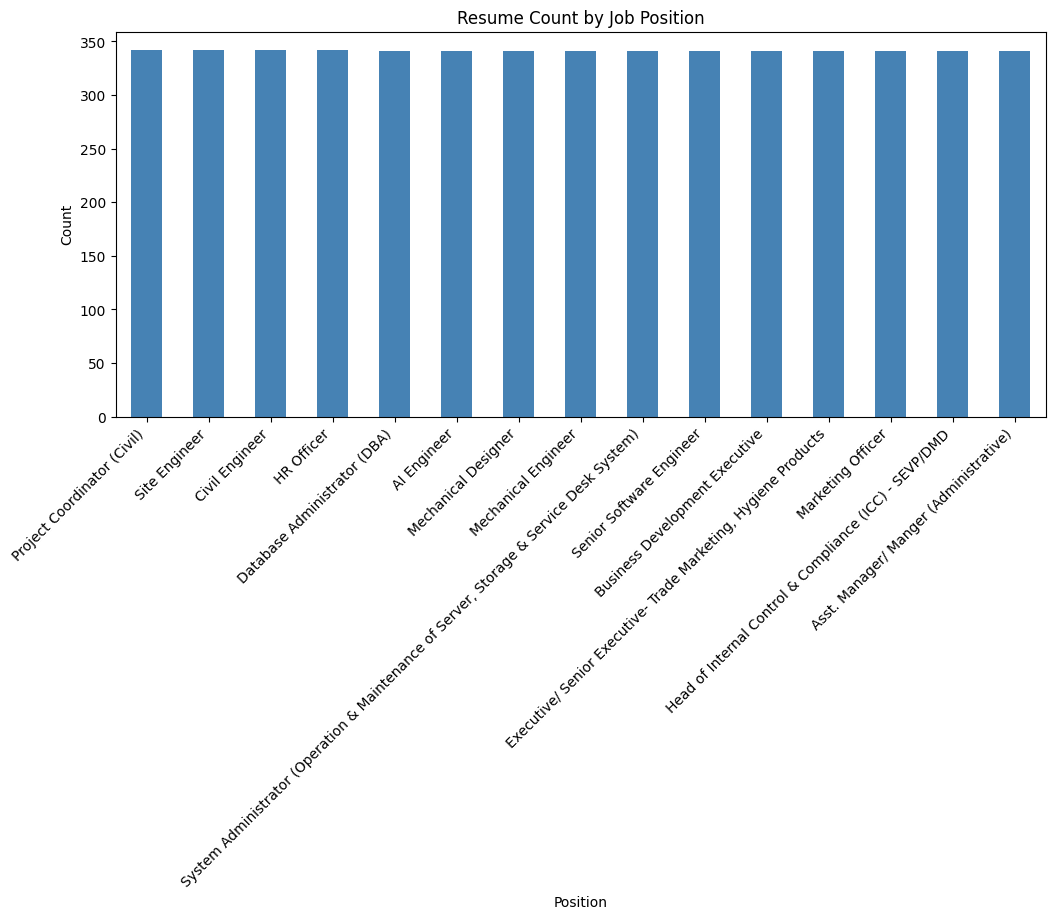

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = ranked_df.head(10).copy()
top10['Rank'] = top10.index

plt.figure(figsize=(12, 5))
sns.barplot(x='Rank', y='match_percent', data=top10, palette='Blues_r')
plt.title('Top 10 Resume Match Scores')
plt.xlabel('Rank')
plt.ylabel('Match Score (%)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
df['job_position_name'].value_counts().head(15).plot(kind='bar', color='steelblue')
plt.title('Resume Count by Job Position')
plt.xlabel('Position')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()